# 台灣高齡人口長照供需落差分析與需求預測

期末專題 — 透過政府公開資料，分析各縣市高齡人口（需求）與長照資源（供給）是否平衡，找出資源相對不足的地區，並預測未來高齡化趨勢與床位缺口。

**資料來源（皆真實政府公開資料）**

| 資料 | 機關 | 年 |
| --- | --- | --- |
| 村里單一年齡人口 (#77132) | 內政部戶政司 | 2025/5 |
| 各縣市老化指數 / 老年比率 | 內政部戶政司 | 2010–2025 |
| 老人福利機構名冊 (#8572) | 衛福部社家署 | 2025 |
| 身心障礙者人數 (年齡×縣市) | 衛福部統計處 | 2025 |

> 執行順序：由上而下逐格執行（Run All）即可。

## 一、環境準備

若尚未安裝套件，先取消下一格註解執行。

In [1]:
# !pip install pandas numpy xlrd openpyxl matplotlib plotly

import os, re, json, glob, urllib.request
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
%matplotlib inline

# 專案根目錄（請依實際路徑調整）
BASE = r"C:\Users\y\03-SQL_Demo\0618"
RAW = os.path.join(BASE, "data", "raw")
OUT = os.path.join(BASE, "output")
PROC = os.path.join(BASE, "data", "processed")
for d in (RAW, OUT, PROC, os.path.join(BASE, "assets")):
    os.makedirs(d, exist_ok=True)

# 中文字型（Windows 內建微軟正黑體）
try:
    FONT = FontProperties(fname=r"C:\Windows\Fonts\msjh.ttc")
    plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
except Exception:
    FONT = FontProperties()
plt.rcParams["axes.unicode_minus"] = False

COUNTIES = ["新北市","臺北市","桃園市","臺中市","臺南市","高雄市","宜蘭縣","新竹縣",
            "苗栗縣","彰化縣","南投縣","雲林縣","嘉義縣","屏東縣","臺東縣","花蓮縣",
            "澎湖縣","基隆市","新竹市","嘉義市","金門縣","連江縣"]
print("環境就緒，BASE =", BASE)

環境就緒，BASE = C:\Users\y\03-SQL_Demo\0618


## 二、資料下載（若 `data/raw/` 已有檔案會自動略過）

透過 data.gov.tw API 與各機關網站抓取真實資料。

In [2]:
UA = {"User-Agent": "Mozilla/5.0"}

def get(url, headers=None, timeout=60):
    req = urllib.request.Request(url, headers={**UA, **(headers or {})})
    return urllib.request.urlopen(req, timeout=timeout).read()

def download(url, path, headers=None):
    if os.path.exists(path) and os.path.getsize(path) > 1000:
        return "已存在"
    data = get(url, headers, timeout=180)
    with open(path, "wb") as f:
        f.write(data)
    return f"下載 {len(data):,} bytes"

def api_dataset(did):
    return json.loads(get(f"https://data.gov.tw/api/v2/rest/dataset/{did}"))["result"]

# 1) 老化指數/老年比率（戶政司）
print("老化指數:", download("https://www.ris.gov.tw/info-popudata/app/awFastDownload/file/y1s4-00000.xls/y1s4/00000/",
                          os.path.join(RAW, "ris_aging_index_by_county.xls")))
# 2) 身心障礙者人數（衛福部統計處）
print("身障(年齡):", download("https://www.mohw.gov.tw/dl-69420-9cfd8264-5caf-47f9-b12d-a23c1c9b22a8.html",
                            os.path.join(RAW, "disability_by_age_county.xls"), {"Referer": "https://dep.mohw.gov.tw/"}))
print("身障(類別):", download("https://www.mohw.gov.tw/dl-69410-3372b4eb-e96d-4b84-ad30-b9f88d657042.html",
                            os.path.join(RAW, "disability_by_type_county.xls"), {"Referer": "https://dep.mohw.gov.tw/"}))
# 3) 縣市界 geojson
print("geojson:", download("https://raw.githubusercontent.com/g0v/twgeojson/master/json/twCounty2010.geo.json",
                          os.path.join(BASE, "assets", "tw_counties.json")))

老化指數: 已存在
身障(年齡): 已存在
身障(類別): 已存在
geojson: 已存在


In [3]:
# 4) 老人福利機構名冊（#8572，22 縣市，Big5）
inst_dir = os.path.join(RAW, "elderly_institutions_8572")
os.makedirs(inst_dir, exist_ok=True)
if len(glob.glob(os.path.join(inst_dir, "*.csv"))) < 22:
    for d in api_dataset(8572)["distribution"]:
        if d.get("resourceFormat") != "CSV":
            continue
        url = d["resourceDownloadUrl"]
        county = urllib.request.unquote(url.split("/")[-1]).replace("老人福利機構名冊.csv", "")
        download(url, os.path.join(inst_dir, county + ".csv"))
print("機構檔數:", len(glob.glob(os.path.join(inst_dir, "*.csv"))))

# 5) 村里單一年齡人口（#77132）：掃描最新期別後下載
pop_path = os.path.join(RAW, "77132_pop_single_age_2025_05.csv")
if not os.path.exists(pop_path):
    best_ym, best_url = 0, None
    for d in api_dataset(77132)["distribution"]:
        if d.get("resourceFormat") != "CSV":
            continue
        try:
            head = get(d["resourceDownloadUrl"], {"Range": "bytes=0-2500"}, timeout=30).decode("utf-8", "ignore")
            mt = re.search(r"\n(\d{5,6})", head)
            if mt and int(mt.group(1)) > best_ym:
                best_ym, best_url = int(mt.group(1)), d["resourceDownloadUrl"]
        except Exception:
            pass
    print("最新期別:", best_ym)
    download(best_url, pop_path)
print("人口檔:", os.path.basename(pop_path), "已就緒")

機構檔數: 22
人口檔: 77132_pop_single_age_2025_05.csv 已就緒


## 三、人口（2025）：縣市總人口、65+、75+

讀取村里單一年齡人口，依「區域別」前 3 字彙整到縣市，加總 65 歲以上與 75 歲以上人口。

In [4]:
pop = pd.read_csv(pop_path)
pop["縣市"] = pop["區域別"].astype(str).str[:3]
pop = pop[pop["縣市"].isin(COUNTIES)].copy()

age_age = {}
for c in pop.columns:
    mt = re.match(r"^(\d+)歲-(男|女)$", str(c))
    if mt:
        age_age.setdefault(int(mt.group(1)), []).append(c)
cols_100 = [c for c in pop.columns if str(c).startswith("100歲以上")]

def ge_cols(lo):
    cs = []
    for a, lst in age_age.items():
        if a >= lo:
            cs += lst
    return cs + cols_100

cols_65, cols_75 = ge_cols(65), ge_cols(75)
for c in ["人口數"] + cols_65 + cols_75:
    pop[c] = pd.to_numeric(pop[c], errors="coerce")

g = pop.groupby("縣市")
pop_df = pd.DataFrame({
    "總人口": g["人口數"].sum().astype(int),
    "老年人口_65歲以上": g[cols_65].sum().sum(axis=1).astype(int),
    "高齡人口_75歲以上": g[cols_75].sum().sum(axis=1).astype(int),
}).reset_index()
pop_df["老年人口比例%"] = (pop_df["老年人口_65歲以上"] / pop_df["總人口"] * 100).round(2)
pop_df["高齡人口比例%"] = (pop_df["高齡人口_75歲以上"] / pop_df["總人口"] * 100).round(2)
pop_df.sort_values("老年人口比例%", ascending=False)

C:\Users\y\AppData\Local\Temp\ipykernel_19016\2860929417.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pop["縣市"] = pop["區域別"].astype(str).str[:3]


,縣市,總人口,老年人口_65歲以上,高齡人口_75歲以上,老年人口比例%,高齡人口比例%
13,臺北市,2427533,596138,245769,24.56,10.12
2,嘉義縣,470857,115525,49135,24.54,10.44
0,南投縣,467338,108137,43381,23.14,9.28
3,基隆市,358829,81599,29157,22.74,8.13
5,屏東縣,779626,173004,67471,22.19,8.65
20,雲林縣,648081,143154,62784,22.09,9.69
16,花蓮縣,311399,68253,26337,21.92,8.46
11,澎湖縣,106675,22905,8910,21.47,8.35
15,臺東縣,208000,44230,17485,21.26,8.41
21,高雄市,2711406,573647,212221,21.16,7.83


## 四、長照供給：老人福利機構數與核定床數

In [5]:
inst_rec = []
for f in glob.glob(os.path.join(inst_dir, "*.csv")):
    county = os.path.splitext(os.path.basename(f))[0]
    d = pd.read_csv(f, encoding="big5", on_bad_lines="skip")
    bed_col = [c for c in d.columns if "床數" in str(c)]
    beds = pd.to_numeric(d[bed_col[0]], errors="coerce").sum() if bed_col else 0
    inst_rec.append({"縣市": county, "機構數": len(d), "核定床數": int(beds)})
inst_df = pd.DataFrame(inst_rec)
inst_df.sort_values("核定床數", ascending=False)

,縣市,機構數,核定床數
7,新北市,214,11076
21,高雄市,155,8283
14,臺南市,121,6190
13,臺北市,103,5401
12,臺中市,66,4077
10,桃園市,69,3982
6,彰化縣,60,3681
5,屏東縣,59,3326
4,宜蘭縣,40,2436
20,雲林縣,42,2063


## 五、身心障礙者人數（需求面輔助）

取最近完整年度分頁，解析各縣市「總計」與「65 歲以上」人數。

In [6]:
xls = pd.ExcelFile(os.path.join(RAW, "disability_by_age_county.xls"))
year_sheets = sorted([s for s in xls.sheet_names if re.fullmatch(r"\d{4}", str(s))], key=int, reverse=True)
dis_df = pd.DataFrame(columns=["縣市", "身障總人數", "身障65歲以上", "身障資料年"])
for sh in year_sheets:
    raw = pd.read_excel(xls, sheet_name=sh, header=None)
    rows = []
    for _, row in raw.iterrows():
        cell0 = str(row[0])
        cm = next((c for c in COUNTIES if c in cell0 or c.replace("臺", "台") in cell0), None)
        if cm:
            nums = pd.to_numeric(row[1:], errors="coerce").dropna()
            if len(nums) >= 2:
                rows.append({"縣市": cm, "身障總人數": int(nums.iloc[0]), "身障65歲以上": int(nums.iloc[-1])})
    if rows:
        dis_df = pd.DataFrame(rows).drop_duplicates("縣市")
        dis_df["身障資料年"] = sh
        print("使用分頁:", sh)
        break
dis_df.head()

使用分頁: 2025


,縣市,身障總人數,身障65歲以上,身障資料年
0,新北市,188268,45567,2025
1,臺北市,121813,35055,2025
2,桃園市,96854,22050,2025
3,臺中市,139638,33938,2025
4,臺南市,102142,27451,2025


## 六、合併縣市主表 + 供需指標

核心指標：**每千名老人核定床數** = 核定床數 ÷ (65+人口 / 1000)。

In [7]:
m = pop_df.merge(inst_df, on="縣市", how="left").merge(dis_df, on="縣市", how="left")
m["每千名老人機構數"] = (m["機構數"] / (m["老年人口_65歲以上"] / 1000)).round(3)
m["每千名老人核定床數"] = (m["核定床數"] / (m["老年人口_65歲以上"] / 1000)).round(2)
median_bed = m["每千名老人核定床數"].median()
m["床數供需指數_對中位數%"] = ((m["每千名老人核定床數"] / median_bed - 1) * 100).round(1)
m["供給不足缺口排名"] = m["每千名老人核定床數"].rank(ascending=True).astype(int)
m = m.sort_values("每千名老人核定床數").reset_index(drop=True)
m.to_csv(os.path.join(PROC, "county_master.csv"), index=False, encoding="utf-8-sig")
print("全國中位數 每千名老人床數 =", median_bed)
m

全國中位數 每千名老人床數 = 14.015


,縣市,總人口,老年人口_65歲以上,高齡人口_75歲以上,老年人口比例%,高齡人口比例%,機構數,核定床數,身障總人數,身障65歲以上,身障資料年,每千名老人機構數,每千名老人核定床數,床數供需指數_對中位數%,供給不足缺口排名
0,臺中市,2867758,508957,178699,17.75,6.23,66,4077,139638,33938,2025,0.130,8.01,-42.8,1
1,新竹市,455797,75023,28679,16.46,6.29,13,617,19169,4658,2025,0.173,8.22,-41.3,2
2,澎湖縣,106675,22905,8910,21.47,8.35,4,206,6375,1705,2025,0.175,8.99,-35.9,3
3,臺北市,2427533,596138,245769,24.56,10.12,103,5401,121813,35055,2025,0.173,9.06,-35.4,4
4,苗栗縣,529981,109099,44255,20.59,8.35,15,1051,34406,9011,2025,0.137,9.63,-31.3,5
5,桃園市,2356302,402852,137749,17.10,5.85,69,3982,96854,22050,2025,0.171,9.88,-29.5,6
6,金門縣,138032,27783,9152,20.13,6.63,2,295,6286,1687,2025,0.072,10.62,-24.2,7
7,嘉義縣,470857,115525,49135,24.54,10.44,28,1414,37605,10785,2025,0.242,12.24,-12.7,8
8,新竹縣,598266,91779,35996,15.34,6.02,18,1218,24561,5487,2025,0.196,13.27,-5.3,9
9,新北市,4039299,822084,285272,20.35,7.06,214,11076,188268,45567,2025,0.260,13.47,-3.9,10


## 七、視覺化

### 7-1 每千名老人核定床數（供需缺口排名）

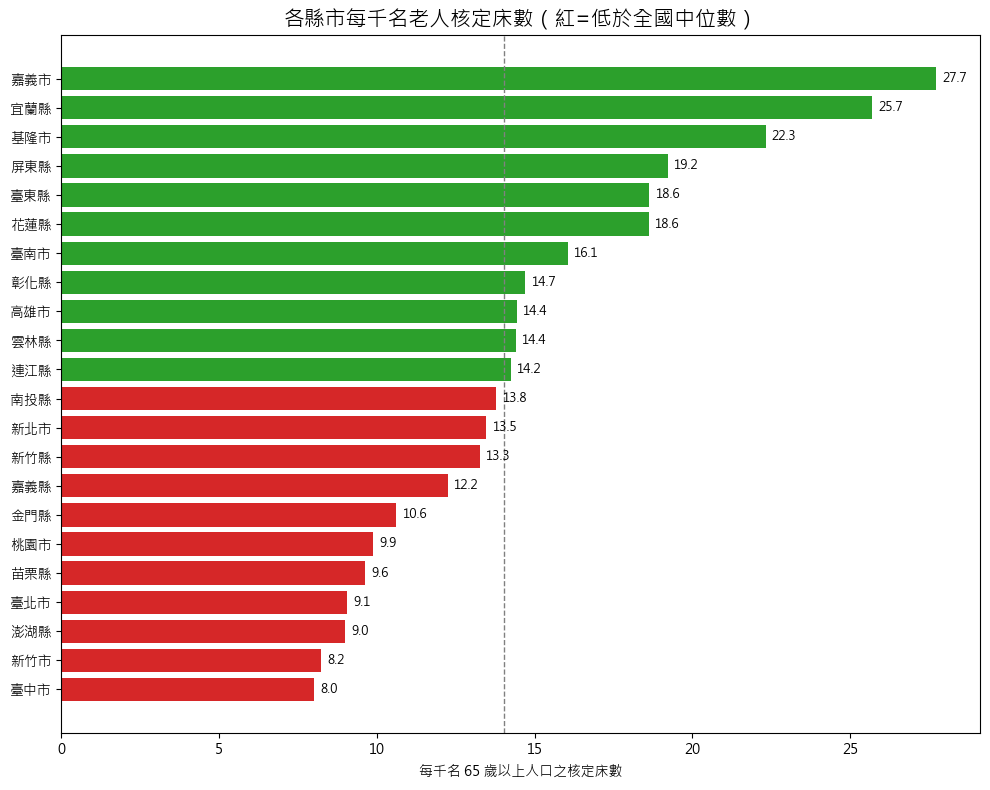

In [8]:
d = m.sort_values("每千名老人核定床數")
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in d["床數供需指數_對中位數%"]]
ax.barh(d["縣市"], d["每千名老人核定床數"], color=colors)
ax.axvline(median_bed, color="gray", ls="--", lw=1)
for i, v in enumerate(d["每千名老人核定床數"]):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9, fontproperties=FONT)
ax.set_title("各縣市每千名老人核定床數（紅=低於全國中位數）", fontproperties=FONT, fontsize=15)
ax.set_xlabel("每千名 65 歲以上人口之核定床數", fontproperties=FONT)
for lab in ax.get_yticklabels():
    lab.set_fontproperties(FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "01_bed_gap_ranking.png"), dpi=130); plt.show()

### 7-2 各縣市老年人口比例

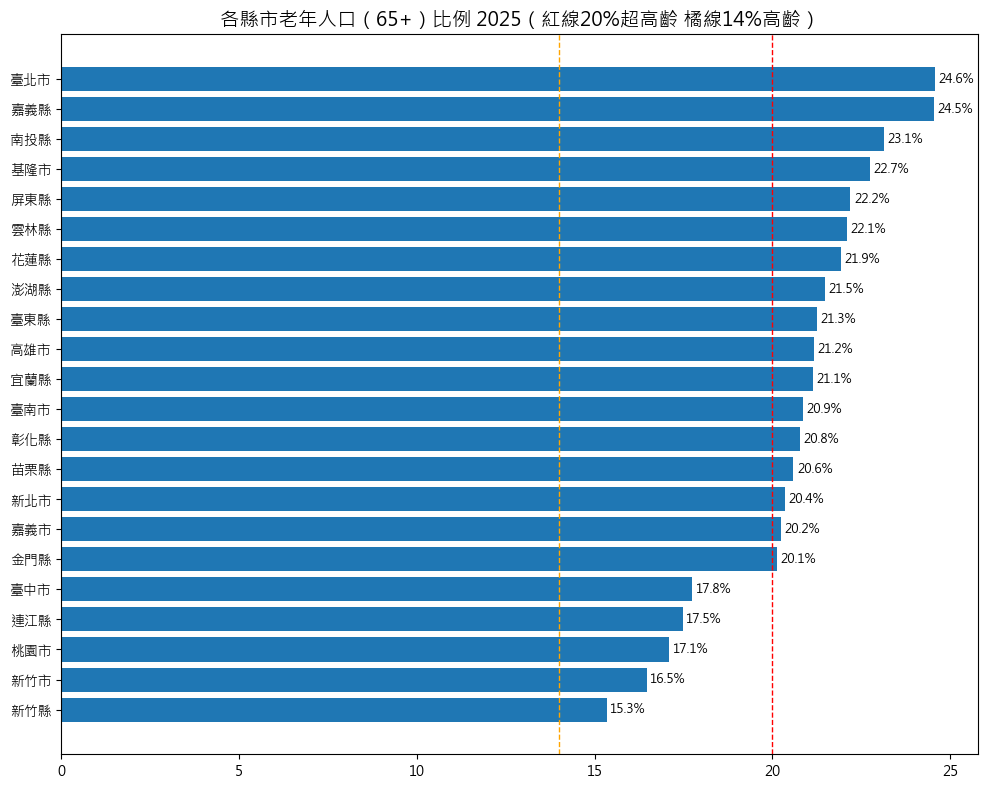

In [9]:
d = m.sort_values("老年人口比例%")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(d["縣市"], d["老年人口比例%"], color="#1f77b4")
ax.axvline(20, color="red", ls="--", lw=1); ax.axvline(14, color="orange", ls="--", lw=1)
for i, v in enumerate(d["老年人口比例%"]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9, fontproperties=FONT)
ax.set_title("各縣市老年人口（65+）比例 2025（紅線20%超高齡 橘線14%高齡）", fontproperties=FONT, fontsize=14)
for lab in ax.get_yticklabels():
    lab.set_fontproperties(FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "02_elderly_ratio.png"), dpi=130); plt.show()

### 7-3 供需散佈：老年人口 vs 核定床數

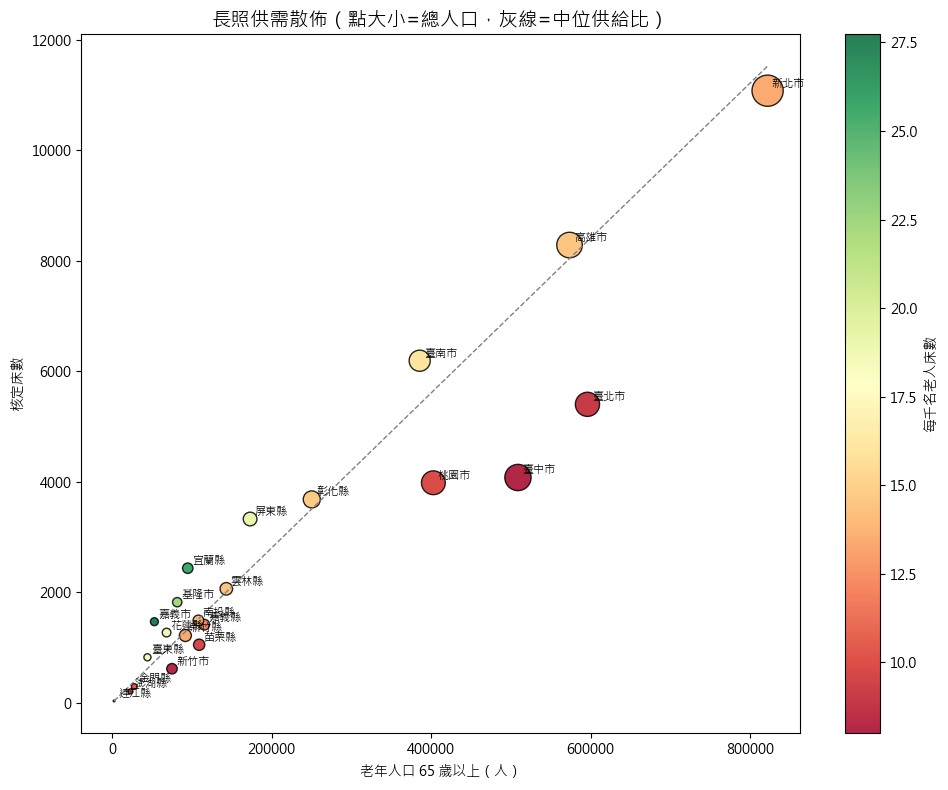

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(m["老年人口_65歲以上"], m["核定床數"], s=m["總人口"]/8000,
                c=m["每千名老人核定床數"], cmap="RdYlGn", edgecolor="k", alpha=0.85)
xs = np.linspace(m["老年人口_65歲以上"].min(), m["老年人口_65歲以上"].max(), 50)
ax.plot(xs, median_bed*xs/1000, "--", color="gray", lw=1)
for _, r in m.iterrows():
    ax.annotate(r["縣市"], (r["老年人口_65歲以上"], r["核定床數"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points", fontproperties=FONT)
plt.colorbar(sc, label="每千名老人床數")
ax.set_title("長照供需散佈（點大小=總人口，灰線=中位供給比）", fontproperties=FONT, fontsize=14)
ax.set_xlabel("老年人口 65 歲以上（人）", fontproperties=FONT); ax.set_ylabel("核定床數", fontproperties=FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "04_supply_demand_scatter.png"), dpi=130); plt.show()

### 7-4 分縣市地圖（choropleth）

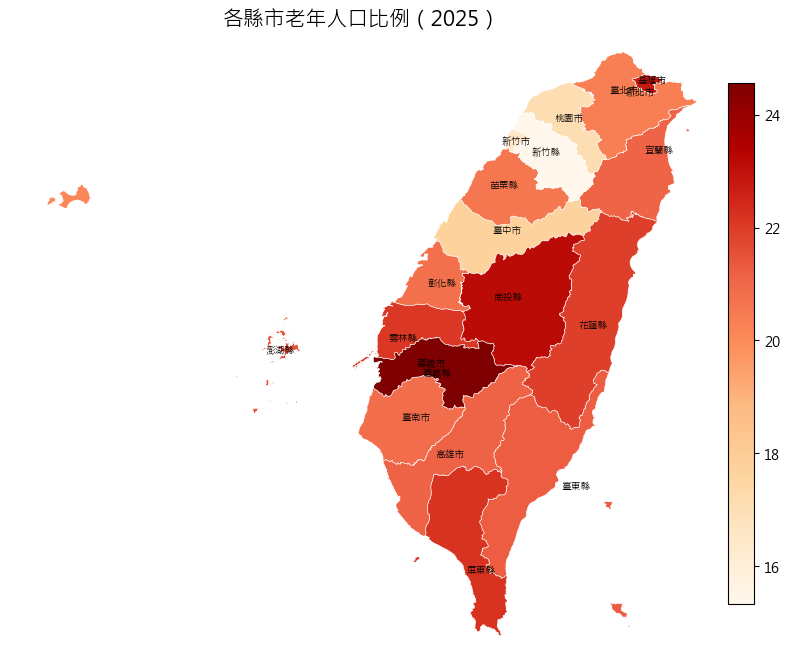

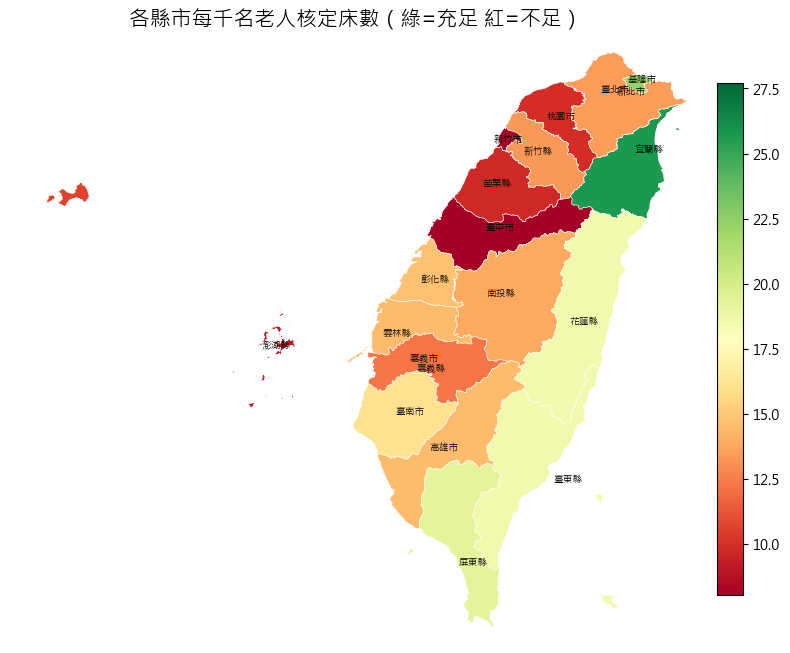

In [11]:
geo = json.load(open(os.path.join(BASE, "assets", "tw_counties.json"), encoding="utf-8"))
def norm_name(n):
    n = n.replace("台", "臺")
    return {"桃園縣": "桃園市"}.get(n, n)

def draw_map(value_col, title, fname, cmap_name):
    vals = m.set_index("縣市")[value_col]
    norm = Normalize(vals.min(), vals.max()); cmap = plt.get_cmap(cmap_name)
    fig, ax = plt.subplots(figsize=(8, 10))
    for feat in geo["features"]:
        name = norm_name(feat["properties"]["COUNTYNAME"]); v = vals.get(name, np.nan)
        color = cmap(norm(v)) if pd.notna(v) else "#dddddd"
        geom = feat["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            ax.add_patch(MplPolygon(np.array(poly[0]), closed=True, facecolor=color, edgecolor="white", lw=0.4))
        pts = np.vstack([np.array(p[0]) for p in polys]); cx, cy = pts[:,0].mean(), pts[:,1].mean()
        if 119.5 < cx < 122.1 and 21.8 < cy < 25.4:
            ax.text(cx, cy, name, fontsize=7, ha="center", va="center", fontproperties=FONT)
    ax.set_xlim(118.0, 122.1); ax.set_ylim(21.8, 25.4); ax.set_aspect("equal"); ax.axis("off")
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([]); plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    ax.set_title(title, fontproperties=FONT, fontsize=15)
    plt.tight_layout(); plt.savefig(os.path.join(OUT, fname), dpi=130); plt.show()

draw_map("老年人口比例%", "各縣市老年人口比例（2025）", "05_map_elderly_ratio.png", "OrRd")
draw_map("每千名老人核定床數", "各縣市每千名老人核定床數（綠=充足 紅=不足）", "06_map_bed_supply.png", "RdYlGn")

## 八、老化指數趨勢（2010–2025）與預測（2026–2030）

以最近 10 年資料對各縣市做線性迴歸外推。

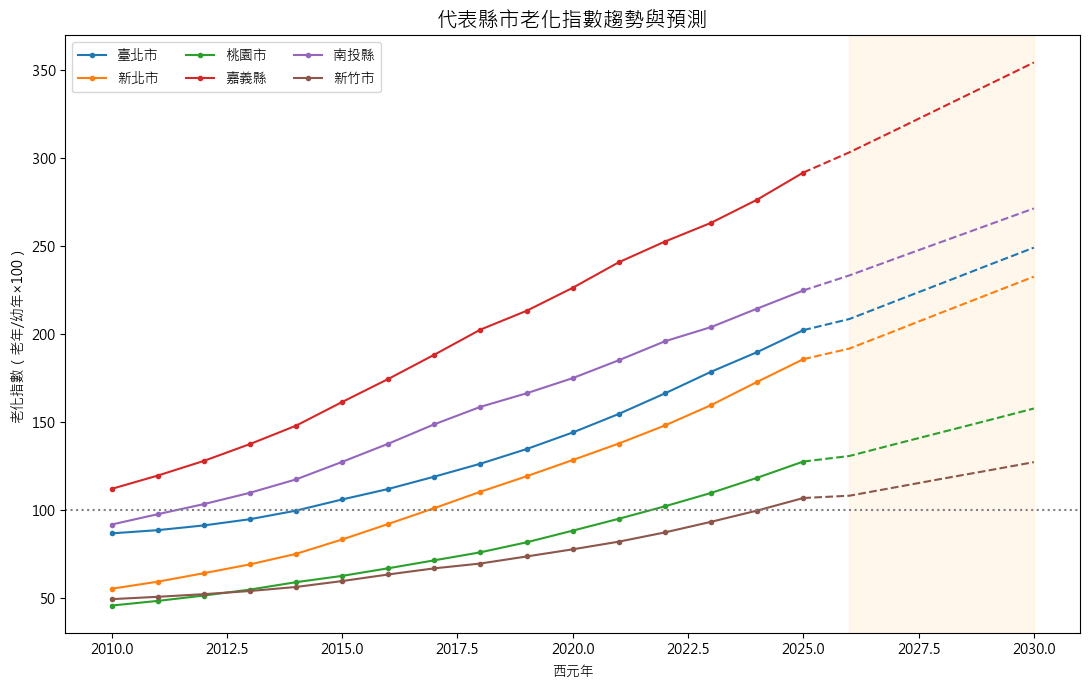

In [12]:
ag = pd.ExcelFile(os.path.join(RAW, "ris_aging_index_by_county.xls"))
# 分頁：[0]三階段人口 [1]老年人口比率 [2]老化指數 ...
def read_county_ts(sheet_idx, value_name):
    t = pd.read_excel(ag, sheet_name=ag.sheet_names[sheet_idx], header=2)
    t = t.rename(columns={t.columns[0]: "縣市"})
    t["縣市"] = t["縣市"].astype(str).str.replace("\u3000", "", regex=False).str.strip()
    t = t[t["縣市"].isin(COUNTIES)]
    ycols = [c for c in t.columns if re.search(r"\d+年", str(c))]
    lg = t.melt(id_vars=["縣市"], value_vars=ycols, var_name="年", value_name=value_name)
    lg["年_西元"] = lg["年"].astype(str).str.extract(r"(\d+)").astype(float) + 1911
    lg[value_name] = pd.to_numeric(lg[value_name], errors="coerce")
    return lg.dropna(subset=["年_西元", value_name]).assign(年_西元=lambda x: x["年_西元"].astype(int))

ts = read_county_ts(2, "老化指數")[["年_西元", "縣市", "老化指數"]]
ts.to_csv(os.path.join(PROC, "aging_index_timeseries.csv"), index=False, encoding="utf-8-sig")

fc, last_year = [], int(ts["年_西元"].max())
for c, gg in ts.groupby("縣市"):
    gg = gg.sort_values("年_西元").tail(10)
    a, b = np.polyfit(gg["年_西元"].astype(float), gg["老化指數"].astype(float), 1)
    for yr in range(last_year+1, last_year+6):
        fc.append({"縣市": c, "年_西元": yr, "老化指數_預測": round(a*yr+b, 1)})
fc = pd.DataFrame(fc)
fc.to_csv(os.path.join(PROC, "forecast_aging_index.csv"), index=False, encoding="utf-8-sig")

reps = ["臺北市", "新北市", "桃園市", "嘉義縣", "南投縣", "新竹市"]
fig, ax = plt.subplots(figsize=(11, 7)); cmap = plt.cm.tab10
for i, c in enumerate(reps):
    a = ts[ts["縣市"] == c].sort_values("年_西元"); f = fc[fc["縣市"] == c].sort_values("年_西元")
    col = cmap(i)
    ax.plot(a["年_西元"], a["老化指數"], "-o", color=col, ms=3, label=c)
    ax.plot([a["年_西元"].iloc[-1]] + list(f["年_西元"]), [a["老化指數"].iloc[-1]] + list(f["老化指數_預測"]), "--", color=col)
ax.axhline(100, color="gray", ls=":"); ax.axvspan(last_year+1, last_year+5, color="orange", alpha=0.08)
ax.legend(prop=FONT, ncol=3); ax.set_title("代表縣市老化指數趨勢與預測", fontproperties=FONT, fontsize=15)
ax.set_xlabel("西元年", fontproperties=FONT); ax.set_ylabel("老化指數（老年/幼年×100）", fontproperties=FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "03_aging_trend_forecast.png"), dpi=130); plt.show()

## 九、需求預測：2030 床位缺口

預測各縣市老年比率 → 估 2030 年 65+ 人口（假設總人口維持 2025 水準）→ 以全國中位服務水準推估所需床數與缺口。

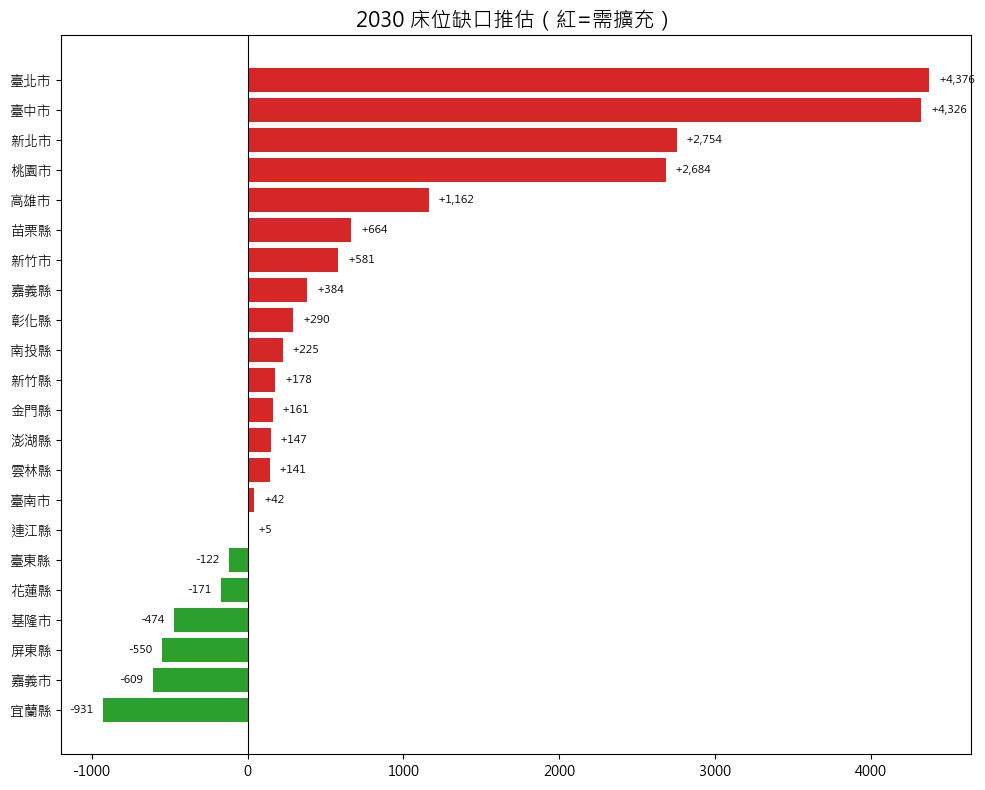

,縣市,老年比率_2030預估%,老年人口_2025,老年人口_2030預估,現有核定床數,2030所需床數,2030床位缺口
0,臺北市,28.74,596138,697671,5401,9777,4376
1,臺中市,20.91,508957,599591,4077,8403,4326
2,新北市,24.43,822084,986811,11076,13830,2754
3,桃園市,20.19,402852,475638,3982,6666,2684
4,高雄市,24.86,573647,673944,8283,9445,1162
5,苗栗縣,23.09,109099,122383,1051,1715,664
6,新竹市,18.76,75023,85520,617,1198,581
7,嘉義縣,27.26,115525,128347,1414,1798,384
8,彰化縣,23.52,250347,283385,3681,3971,290
9,南投縣,26.21,108137,122476,1491,1716,225


In [13]:
rate = read_county_ts(1, "老年比率")
tot = pop_df.set_index("縣市")["總人口"]; beds_now = m.set_index("縣市")["核定床數"]
drec = []
for c, gg in rate.groupby("縣市"):
    gg = gg.sort_values("年_西元").tail(10)
    a, b = np.polyfit(gg["年_西元"].astype(float), gg["老年比率"].astype(float), 1)
    p65_2030 = (a*2030 + b)/100 * tot.get(c, np.nan)
    need = p65_2030/1000 * median_bed
    drec.append({"縣市": c, "老年比率_2030預估%": round(a*2030+b, 2),
                 "老年人口_2025": int(m.set_index('縣市').loc[c, '老年人口_65歲以上']),
                 "老年人口_2030預估": int(p65_2030), "現有核定床數": int(beds_now.get(c, 0)),
                 "2030所需床數": int(need), "2030床位缺口": int(need - beds_now.get(c, 0))})
dem = pd.DataFrame(drec).sort_values("2030床位缺口", ascending=False).reset_index(drop=True)
dem.to_csv(os.path.join(PROC, "forecast_bed_demand_2030.csv"), index=False, encoding="utf-8-sig")

d = dem.sort_values("2030床位缺口")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(d["縣市"], d["2030床位缺口"], color=["#2ca02c" if v <= 0 else "#d62728" for v in d["2030床位缺口"]])
ax.axvline(0, color="k", lw=0.8)
for i, v in enumerate(d["2030床位缺口"]):
    ax.text(v + (60 if v >= 0 else -60), i, f"{v:+,}", va="center", ha="left" if v >= 0 else "right", fontsize=8, fontproperties=FONT)
ax.set_title("2030 床位缺口推估（紅=需擴充）", fontproperties=FONT, fontsize=15)
for lab in ax.get_yticklabels():
    lab.set_fontproperties(FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "07_bed_demand_gap_2030.png"), dpi=130); plt.show()
dem

## 十、修正分析：用「長照服務涵蓋率」檢視真實供需缺口

> **為什麼要修正？** 前面用「每千名老人核定床數」當供給指標有兩個結構性偏誤：
> 1. **沒算照護人力**——床位是死的，沒有照服員，床位再多也是空的（偏鄉常「有床無人顧」）。
> 2. **比率會騙人**——偏鄉老人絕對數少，只要一兩家機構，每千老人床數就很高，被誤判為「充足」。
>
> 衛福部長照 2.0 以 **失能推估需求人數** 為分母的「**長照服務涵蓋率**」是更貼近真實的供需指標：
> 分子為實際使用長照服務的人數（內含居家/社區/機構各式服務），間接反映人力是否到位。
> 涵蓋率越低 = 需求未被滿足越嚴重。

In [14]:
# 下載衛福部長照專區 PDF（涵蓋率、ABC據點），已存在則略過
# !pip install pdfplumber
import pdfplumber
_pdfs = {
    'ltc_coverage_rate.pdf': 'https://www.mohw.gov.tw/dl-88608-9d7a650b-ac63-43cb-a469-7d1cb37a2d77.html',
    'ltc_county_resources.pdf': 'https://www.mohw.gov.tw/dl-89795-52476cf8-4945-4713-9053-80ea95723d9d.html',
}
for fn, url in _pdfs.items():
    p = os.path.join(RAW, fn)
    if not (os.path.exists(p) and os.path.getsize(p) > 1000):
        with open(p, 'wb') as f:
            f.write(get(url, {'Referer': 'https://1966.gov.tw/'}, timeout=120))
    print(fn, '就緒')

ltc_coverage_rate.pdf 就緒
ltc_county_resources.pdf 就緒


In [15]:
# 解析 PDF → 涵蓋率 / ABC據點，並合併進主表
def _num(s): return float(s.replace(',', '').replace('%', ''))

cov_rows = []
with pdfplumber.open(os.path.join(RAW, 'ltc_coverage_rate.pdf')) as pdf:
    for pg in pdf.pages:
        for ln in (pg.extract_text() or '').split('\n'):
            t = ln.split()
            if len(t) >= 7 and ''.join(t[:-6]) in COUNTIES:
                cov_rows.append({'縣市': ''.join(t[:-6]),
                                 '長照推估需求人數': int(_num(t[-6])),
                                 '長照服務涵蓋率%': round(_num(t[-1]), 2),
                                 '未滿足需求比例%': round(100 - _num(t[-1]), 2)})
cov = pd.DataFrame(cov_rows).drop_duplicates('縣市')

res_rows = []
with pdfplumber.open(os.path.join(RAW, 'ltc_county_resources.pdf')) as pdf:
    for pg in pdf.pages:
        for ln in (pg.extract_text() or '').split('\n'):
            t = ln.split()
            if len(t) >= 10 and ''.join(t[:-9]) in COUNTIES:
                v = [_num(x) for x in t[-9:]]
                res_rows.append({'縣市': ''.join(t[:-9]), 'A達成率%': round(v[2], 1),
                                 'B特約單位_實際': int(v[4]), 'C巷弄站_實際': int(v[7])})
res = pd.DataFrame(res_rows).drop_duplicates('縣市')

m = m.merge(cov, on='縣市', how='left').merge(res, on='縣市', how='left')

def _z(s, invert=False):
    s = pd.to_numeric(s, errors='coerce'); zz = (s - s.mean()) / s.std(ddof=0)
    return -zz if invert else zz
m['脆弱度指數'] = (pd.concat([_z(m['未滿足需求比例%']), _z(m['高齡人口比例%']),
                          _z(m['A達成率%'], invert=True)], axis=1).mean(axis=1)).round(3)
m['涵蓋率缺口排名'] = m['長照服務涵蓋率%'].rank(ascending=True).astype(int)
m.to_csv(os.path.join(PROC, 'county_master.csv'), index=False, encoding='utf-8-sig')
m[['縣市', '長照推估需求人數', '長照服務涵蓋率%', '未滿足需求比例%', '每千名老人核定床數', '脆弱度指數']].sort_values('長照服務涵蓋率%')

,縣市,長照推估需求人數,長照服務涵蓋率%,未滿足需求比例%,每千名老人核定床數,脆弱度指數
11,連江縣,412,33.50,66.50,14.24,0.915
6,金門縣,4904,43.25,56.75,10.62,0.850
3,臺北市,113710,58.10,41.90,9.06,0.824
19,基隆市,15102,70.06,29.94,22.32,0.442
1,新竹市,14186,76.55,23.45,8.22,-0.204
5,桃園市,70889,77.75,22.25,9.88,-0.928
4,苗栗縣,21724,78.32,21.68,9.63,0.103
8,新竹縣,17895,78.82,21.18,13.27,-0.161
9,新北市,146627,79.90,20.10,13.47,-0.494
2,澎湖縣,4207,82.05,17.95,8.99,0.420


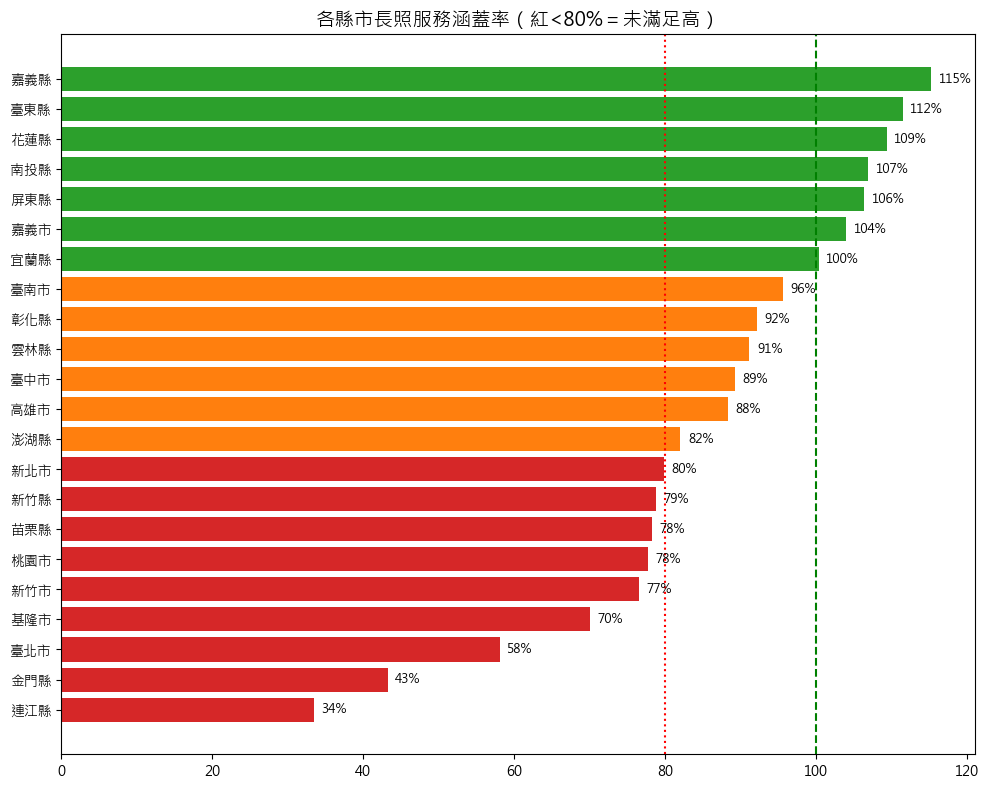

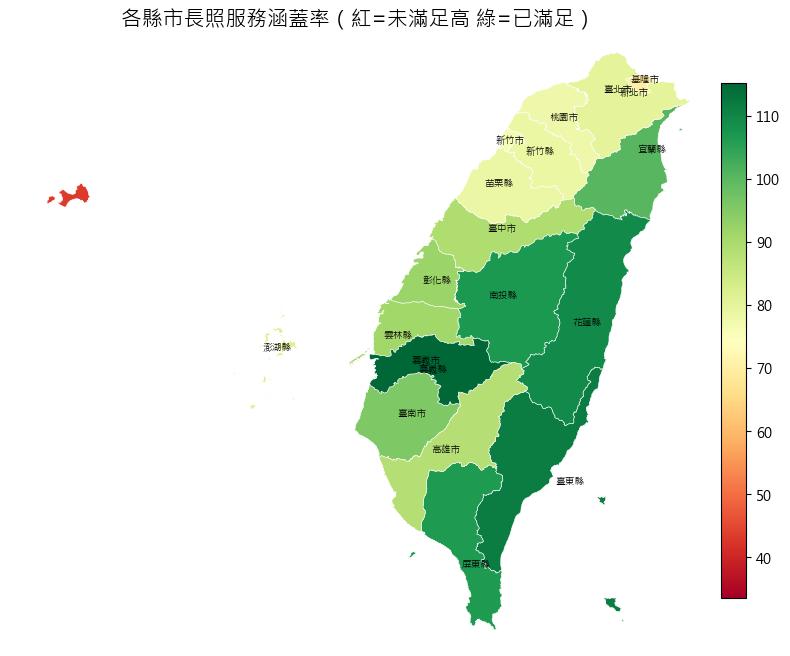

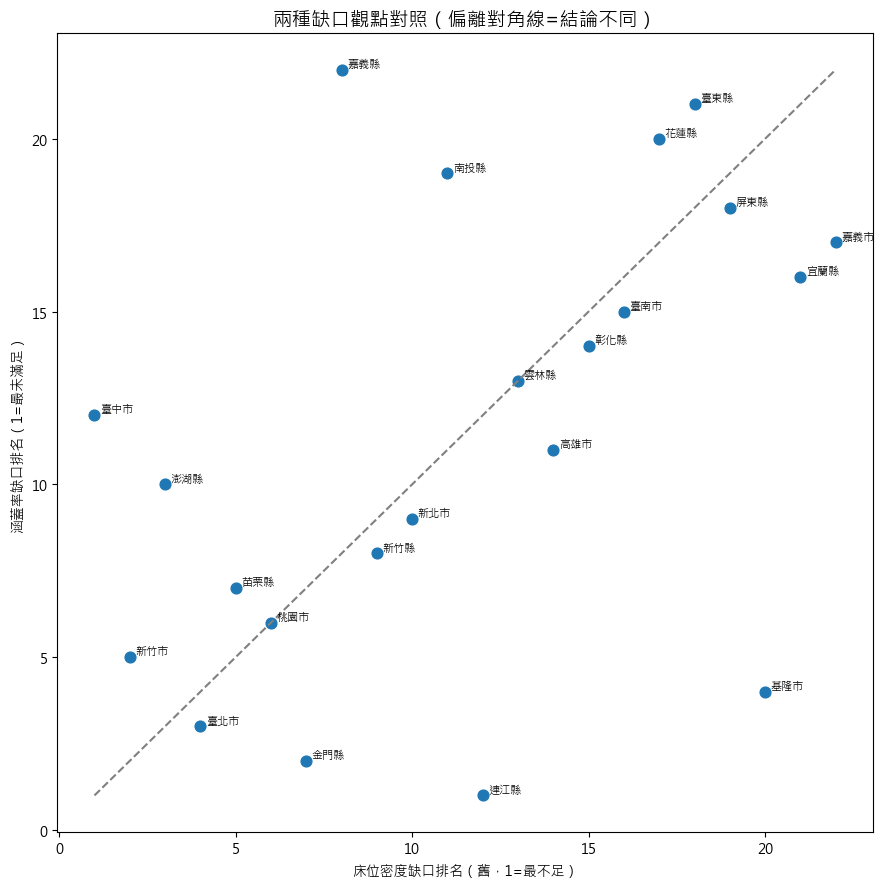

In [16]:
# 涵蓋率排名 + 涵蓋率地圖 + 新舊觀點對照
d = m.sort_values('長照服務涵蓋率%')
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if v < 80 else ('#ff7f0e' if v < 100 else '#2ca02c') for v in d['長照服務涵蓋率%']]
ax.barh(d['縣市'], d['長照服務涵蓋率%'], color=colors)
ax.axvline(100, color='green', ls='--'); ax.axvline(80, color='red', ls=':')
for i, v in enumerate(d['長照服務涵蓋率%']):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontproperties=FONT)
ax.set_title('各縣市長照服務涵蓋率（紅<80%＝未滿足高）', fontproperties=FONT, fontsize=14)
for lab in ax.get_yticklabels(): lab.set_fontproperties(FONT)
plt.tight_layout(); plt.savefig(os.path.join(OUT, '08_coverage_rate_ranking.png'), dpi=130); plt.show()

draw_map('長照服務涵蓋率%', '各縣市長照服務涵蓋率（紅=未滿足高 綠=已滿足）', '09_map_coverage_rate.png', 'RdYlGn')

fig, ax = plt.subplots(figsize=(9, 9))
bed_rank = m['每千名老人核定床數'].rank(ascending=True).astype(int)
ax.scatter(bed_rank, m['涵蓋率缺口排名'], s=60, color='#1f77b4')
for i, r in m.reset_index(drop=True).iterrows():
    ax.annotate(r['縣市'], (bed_rank.iloc[i], r['涵蓋率缺口排名']), fontsize=8,
                xytext=(4, 2), textcoords='offset points', fontproperties=FONT)
ax.plot([1, 22], [1, 22], '--', color='gray')
ax.set_xlabel('床位密度缺口排名（舊，1=最不足）', fontproperties=FONT)
ax.set_ylabel('涵蓋率缺口排名（1=最未滿足）', fontproperties=FONT)
ax.set_title('兩種缺口觀點對照（偏離對角線=結論不同）', fontproperties=FONT, fontsize=14)
plt.tight_layout(); plt.savefig(os.path.join(OUT, '10_rank_comparison.png'), dpi=130); plt.show()

### 修正後的發現（誠實校正）

用「長照服務涵蓋率」（以失能推估需求為分母）重新檢視，結論與「只看床位密度」**幾乎相反**：

| 觀點 | 最危險（前幾名） | 看似安全 |
| --- | --- | --- |
| 舊：每千名老人床位密度 | 臺中、新竹市、臺北、苗栗、桃園（都會） | 嘉義市、宜蘭、基隆、臺東 |
| 新：長照服務涵蓋率 | **連江 33%、金門 43%、臺北 58%、基隆 70%、新竹市 77%、桃園 78%** | **臺東 112%、花蓮 109%、嘉義縣 115%、屏東 106%** |

**三個重點：**

1. **離島最危險（你的直覺正確）**：連江 33.5%、金門 43.3% 涵蓋率全國墊底，正因人口少、難布建 A 整合中心（連江 A 達成率 0%、金門 40%）、難留照護人力——這正是「老人少但沒人顧」的寫照。舊的床位指標完全漏掉它們。

2. **東部、南部其實涵蓋良好（與直覺相反）**：臺東、花蓮、嘉義、屏東、南投涵蓋率都 >100%，因長照 2.0 在當地 ABC 據點布建積極（達成率常 200%~500%）、戶籍需求基數較小、且有跨縣市機構使用。**所以「南部/東部更危險」在這份資料上不成立。**

3. **真正高風險是「離島 + 北部都會圈」**：臺北 58%（第 3 低）、基隆 70%、桃園 78%、新北 80%、新竹市 77%——都會的缺口是真的，但成因是龐大需求 + 都會居民多用外勞/自費而非長照 2.0 給付，與我原本「床位太少」的解讀不同。

> **方法反省**：單一比率指標（尤其分母用老人數）很容易誤導；應以「**失能需求 vs 實際服務遞送**」的涵蓋率為主軸，並輔以深度老化、整合資源布建（A 達成率）等多維度脆弱度，才能避免把都會的稀釋效應或偏鄉的小基數效應誤判為供需結論。

## 十一、結論與政策建議（修正版）

**以「長照服務涵蓋率」(失能需求 vs 實際服務) 為主軸的真實供需缺口：**

- **最高風險 = 離島 + 北部都會圈**：連江(33%)、金門(43%)、臺北(58%)、基隆(70%)、新竹市(77%)、桃園(78%)、苗栗(78%)、新北(80%)。
- **離島**因規模小、布建難、人力難留，是結構性最弱環節（連江 A 整合中心達成率 0%）。
- **北部都會**缺口來自龐大需求與長照 2.0 給付使用率偏低。
- **東部、南部反而涵蓋良好**（臺東/花蓮/嘉義/屏東/南投 >100%），長照 2.0 布建已見成效。

**政策建議**：
1. **離島**：採在地培力 + 跨縣市支援 + 遠距/巡迴照護，補 A/C 據點與人力缺口。
2. **北部都會**：提升長照 2.0 給付服務使用率、銜接外勞與正式服務、擴居家/社區量能。
3. 資源配置應以「**涵蓋率**」與「**失能需求成長**」為依據，而非單純床位數。

**限制**：涵蓋率分母為戶籍失能推估、分子依實際服務地計算，跨縣市使用會使部分縣市 >100%；
床位數僅機構住宿式供給；本分析未能取得各縣市「照顧服務員實際在職人數」之開放資料，
以涵蓋率與 A 整合中心達成率作為人力到位的間接代理指標。